In [1]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

/Users/makafuiayegbe/Code/Data Analyst Projects/toronto-affordability-index/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


All imports successful


In [2]:
import urllib.request
import zipfile
import os

# Download Toronto neighbourhood shapefiles
url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/4def3f65-2a65-4a4f-83A4-be5254b0f309/resource/a083c865-6d60-4d1d-b6c6-b0c8a85f9c15/download/Neighbourhoods%20-%204326.zip"

os.makedirs("../data", exist_ok=True)

urllib.request.urlretrieve(url, "../data/toronto_neighbourhoods.zip")

with zipfile.ZipFile("../data/toronto_neighbourhoods.zip", "r") as z:
    z.extractall("../data/toronto_neighbourhoods")

print("Download complete")
print(os.listdir("../data/toronto_neighbourhoods"))

HTTPError: HTTP Error 404: Not Found

In [3]:
import urllib.request
import zipfile
import os

# Download Toronto neighbourhood shapefiles
url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/4def3f65-2a65-4a4f-83A4-be5254b0f309/resource/a083c865-6d60-4d1d-b6c6-b0c8a85f9c15/download/Neighbourhoods%20-%204326.zip"

os.makedirs("../data", exist_ok=True)

urllib.request.urlretrieve(url, "../data/toronto_neighbourhoods.zip")

with zipfile.ZipFile("../data/toronto_neighbourhoods.zip", "r") as z:
    z.extractall("../data/toronto_neighbourhoods")

print("Download complete")
print(os.listdir("../data/toronto_neighbourhoods"))

HTTPError: HTTP Error 404: Not Found

In [4]:
# Load Toronto neighbourhood boundaries
neighbourhoods = gpd.read_file("../data/Neighbourhoods_4326.geojson")

print(neighbourhoods.shape)
print(neighbourhoods.columns.tolist())
neighbourhoods.head()

(158, 12)
['_id', 'AREA_ID', 'AREA_ATTR_ID', 'PARENT_AREA_ID', 'AREA_SHORT_CODE', 'AREA_LONG_CODE', 'AREA_NAME', 'AREA_DESC', 'CLASSIFICATION', 'CLASSIFICATION_CODE', 'OBJECTID', 'geometry']


,_id,AREA_ID,AREA_ATTR_ID,PARENT_AREA_ID,AREA_SHORT_CODE,AREA_LONG_CODE,AREA_NAME,AREA_DESC,CLASSIFICATION,CLASSIFICATION_CODE,OBJECTID,geometry
0,1,2502366,26022881,None,174,174,South Eglinton-Davisville,South Eglinton-Davisville (174),Not an NIA or Emerging Neighbourhood,NA,17824737.0,"MULTIPOLYGON (((-79.38635 43.69783, -79.38623 ..."
1,2,2502365,26022880,None,173,173,North Toronto,North Toronto (173),Not an NIA or Emerging Neighbourhood,NA,17824753.0,"MULTIPOLYGON (((-79.39744 43.70693, -79.39837 ..."
2,3,2502364,26022879,None,172,172,Dovercourt Village,Dovercourt Village (172),Not an NIA or Emerging Neighbourhood,NA,17824769.0,"MULTIPOLYGON (((-79.43411 43.66015, -79.43537 ..."
3,4,2502363,26022878,None,171,171,Junction-Wallace Emerson,Junction-Wallace Emerson (171),Not an NIA or Emerging Neighbourhood,NA,17824785.0,"MULTIPOLYGON (((-79.4387 43.66766, -79.43841 4..."
4,5,2502362,26022877,None,170,170,Yonge-Bay Corridor,Yonge-Bay Corridor (170),Not an NIA or Emerging Neighbourhood,NA,17824801.0,"MULTIPOLYGON (((-79.38404 43.64497, -79.38502 ..."


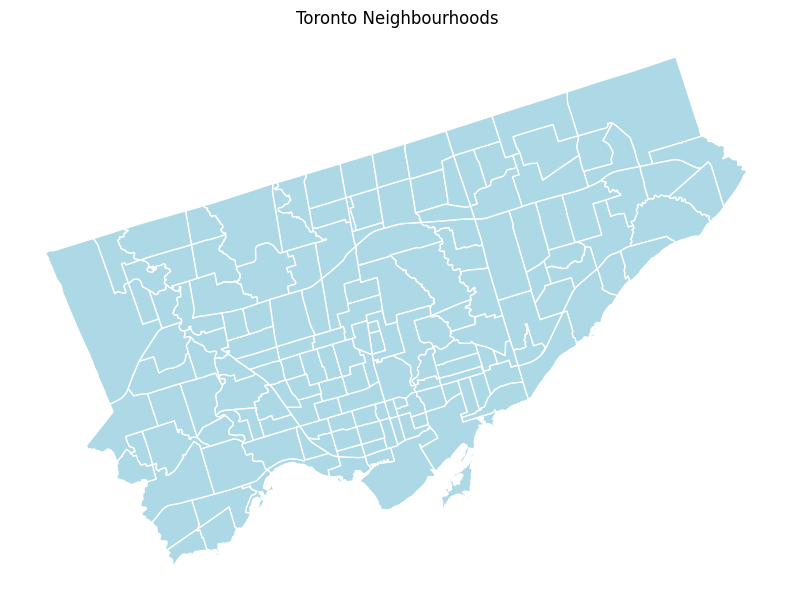

In [5]:
# filter what i need
neighbourhoods = neighbourhoods[['AREA_NAME', 'geometry']]

# visual check... plot neighbourhoods
neighbourhoods.plot(figsize=(10, 10), color='lightblue', edgecolor='white')
plt.title("Toronto Neighbourhoods")
plt.axis('off')
plt.show()

In [6]:
# load data
rentals = pd.read_csv("../data/rentfaster.csv")

print(rentals.shape)
print(rentals.columns.tolist())
rentals.head()

(25771, 18)
['rentfaster_id', 'city', 'province', 'address', 'latitude', 'longitude', 'lease_term', 'type', 'price', 'beds', 'baths', 'sq_feet', 'link', 'furnishing', 'availability_date', 'smoking', 'cats', 'dogs']


,rentfaster_id,city,province,address,latitude,longitude,lease_term,type,price,beds,baths,sq_feet,link,furnishing,availability_date,smoking,cats,dogs
0,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2495.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
1,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2695.0,3 Beds,2.5,1496,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
2,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2295.0,2 Beds,2.5,1180,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
3,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2095.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,November 18,Non-Smoking,True,True
4,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2495.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True


In [7]:
# filter for Toronto only
toronto_rentals = rentals[rentals['city'].str.lower() == 'toronto']

print(f"Total listings: {len(toronto_rentals)}")
print(f"Price range: ${toronto_rentals['price'].min()} - ${toronto_rentals['price'].max()}")
print(f"Nulls:\n{toronto_rentals[['price', 'beds', 'latitude', 'longitude']].isnull().sum()}")
toronto_rentals.head()

Total listings: 2893
Price range: $0.0 - $19170.0
Nulls:
price        0
beds         0
latitude     0
longitude    0
dtype: int64


,rentfaster_id,city,province,address,latitude,longitude,lease_term,type,price,beds,baths,sq_feet,link,furnishing,availability_date,smoking,cats,dogs
19563,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,2227.0,Studio,1,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
19564,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,2299.0,1 Bed,1,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
19565,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,2668.0,1 Bed,2,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
19566,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,3812.0,2 Beds,2,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
19567,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,4124.0,3 Beds,2,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True


In [8]:
# get Toronot copy
toronto_rentals = rentals[rentals['city'] == 'Toronto'].copy()

# converting beds text to numbers
beds_mapping = {
    'Studio': 0.5,
    'Bachelor': 0.5,
    '1 Bed': 1,
    '2 Beds': 2,
    '3 Beds': 3,
    '4 Beds': 4,
    '5 Beds': 5,
    '6 Beds': 6,
}
toronto_rentals['beds'] = toronto_rentals['beds'].map(beds_mapping)

# Convert price
toronto_rentals['price'] = pd.to_numeric(toronto_rentals['price'], errors='coerce')

# Drop nulls
toronto_rentals = toronto_rentals.dropna(subset=['price', 'beds', 'latitude', 'longitude'])

# Filter outliers
toronto_rentals = toronto_rentals[
    (toronto_rentals['price'] >= 500) &
    (toronto_rentals['price'] <= 10000)
]

print(f"Cleaned listings: {len(toronto_rentals)}")
print(f"Price range: ${toronto_rentals['price'].min()} - ${toronto_rentals['price'].max()}")
print(f"Avg price: ${toronto_rentals['price'].mean():.2f}")
print(f"Bed types: {sorted(toronto_rentals['beds'].unique())}")

Cleaned listings: 2778
Price range: $1300.0 - $9995.0
Avg price: $2909.37
Bed types: [np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]


In [9]:
from shapely.geometry import Point

# change rentals data to a GeoDataFrame
toronto_rentals_geo = gpd.GeoDataFrame(
    toronto_rentals,
    geometry=gpd.points_from_xy(toronto_rentals['longitude'], toronto_rentals['latitude']),
    crs="EPSG:4326"
)

# make a spatial join to match each listing to a neighbourhood
joined = gpd.sjoin(toronto_rentals_geo, neighbourhoods, how='left', predicate='within')

print(f"Listings matched to a neighbourhood: {joined['AREA_NAME'].notna().sum()}")
print(f"Listings not matched: {joined['AREA_NAME'].isna().sum()}")
print(joined[['price', 'beds', 'AREA_NAME']].head(10))

Listings matched to a neighbourhood: 2773
Listings not matched: 5
        price  beds             AREA_NAME
19563  2227.0   0.5      Wellington Place
19564  2299.0   1.0      Wellington Place
19565  2668.0   1.0      Wellington Place
19566  3812.0   2.0      Wellington Place
19567  4124.0   3.0      Wellington Place
19568  5264.0   3.0      Wellington Place
19569  3999.0   3.0  Briar Hill-Belgravia
19570  3999.0   2.0  Briar Hill-Belgravia
19571  3999.0   3.0  Briar Hill-Belgravia
19572  3150.0   2.0  Briar Hill-Belgravia


In [10]:
# calculate average price per neighbourhood
neighbourhood_avg = joined.groupby('AREA_NAME').agg(
    avg_rent=('price', 'mean'),
    listing_count=('price', 'count')
).reset_index()

# remove neighbourhoods with fewer than 3 listings because the amount of data is small
neighbourhood_avg = neighbourhood_avg[neighbourhood_avg['listing_count'] >= 3]

print(f"Neighbourhoods with enough data: {len(neighbourhood_avg)}")
print(neighbourhood_avg.sort_values('avg_rent', ascending=False).head(10))

Neighbourhoods with enough data: 109
                     AREA_NAME     avg_rent  listing_count
106          Trinity-Bellwoods  4176.772857              7
22          Danforth East York  4114.666667              3
109           Wellington Place  3803.708333            120
27         Downtown Yonge East  3639.475352            284
16                   Casa Loma  3480.637000             40
5               Bay-Cloverhill  3477.839286             56
82     Palmerston-Little Italy  3377.500000              4
119         Yonge-Bay Corridor  3360.937500             16
79                    Oakridge  3338.882353             85
40   Fort York-Liberty Village  3338.311111             45


In [11]:
# toronto median household income from stats canada 2021
MEDIAN_MONTHLY_INCOME = 7000  # $84,000 / 12
AFFORDABILITY_THRESHOLD = 0.30

# calc affordability ratio per neighbourhood
neighbourhood_avg['affordability_ratio'] = (
    neighbourhood_avg['avg_rent'] / MEDIAN_MONTHLY_INCOME
)

# mark whether neighbourhood is affordable or not
neighbourhood_avg['is_unaffordable'] = (
    neighbourhood_avg['affordability_ratio'] > AFFORDABILITY_THRESHOLD
)

unaffordable_count = neighbourhood_avg['is_unaffordable'].sum()
print(f"Unaffordable neighbourhoods: {unaffordable_count} / {len(neighbourhood_avg)}")
print(f"\nMost affordable neighbourhoods:")
print(neighbourhood_avg.sort_values('affordability_ratio').head(10)[['AREA_NAME', 'avg_rent', 'affordability_ratio']])
print(f"\nLeast affordable neighbourhoods:")
print(neighbourhood_avg.sort_values('affordability_ratio', ascending=False).head(10)[['AREA_NAME', 'avg_rent', 'affordability_ratio']])

Unaffordable neighbourhoods: 102 / 109

Most affordable neighbourhoods:
                   AREA_NAME     avg_rent  affordability_ratio
43         Greenwood-Coxwell  1439.800000             0.205686
8    Beechborough-Greenbrook  1866.000000             0.266571
69              Mount Dennis  1886.000000             0.269429
80           Oakwood Village  1938.000000             0.276857
110   West Humber-Clairville  2021.000000             0.288714
117        Woodbine Corridor  2051.585000             0.293084
10     Birchcliffe-Cliffside  2085.000000             0.297857
56      Kensington-Chinatown  2109.730769             0.301390
72               New Toronto  2141.944444             0.305992
15        Caledonia-Fairbank  2150.600000             0.307229

Least affordable neighbourhoods:
                     AREA_NAME     avg_rent  affordability_ratio
106          Trinity-Bellwoods  4176.772857             0.596682
22          Danforth East York  4114.666667             0.587810
109   

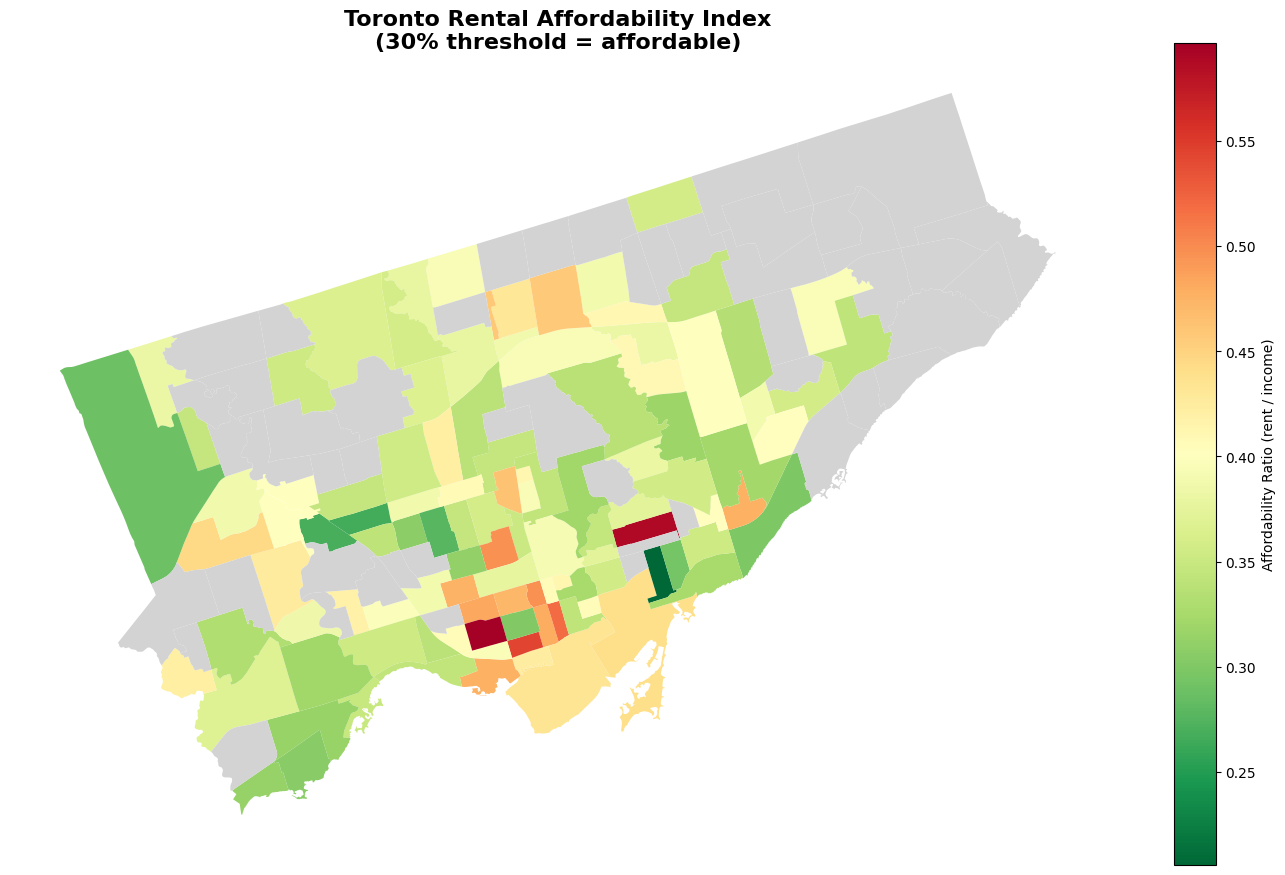

Map saved to visuals/affordability_map.png


In [12]:
# merge affordability data back onto the neighbourhood geodataframe
map_data = neighbourhoods.merge(neighbourhood_avg, on='AREA_NAME', how='left')

# plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

map_data.plot(
    column='affordability_ratio',
    ax=ax,
    cmap='RdYlGn_r',  # red = unaffordable, green = affordable
    legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    legend_kwds={'label': 'Affordability Ratio (rent / income)', 'shrink': 0.6}
)

ax.set_title('Toronto Rental Affordability Index\n(30% threshold = affordable)', 
             fontsize=16, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('../visuals/affordability_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("Map saved to visuals/affordability_map.png")